In [37]:
import duckdb
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StructType, StructField, IntegerType, LongType, DoubleType, BooleanType, TimestampType
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

## A. Quan sát và phân tích Dim Companies

In [38]:
spark = SparkSession.builder.appName("Companies").getOrCreate()

In [39]:
# Connect to the DuckDB database
duck_conn = duckdb.connect(database='/home/nvkhoa14/stock-data-engineering/datawarehouse.duckdb')
query = 'SELECT * FROM dim_companies'

# Fetch data from DuckDB and convert to Pandas DataFrame
pandas_df = duck_conn.execute(query).fetchdf()

duck_conn.close()

In [40]:
# Convert Pandas DataFrame to PySpark DataFrame
spark_df_companies = spark.createDataFrame(pandas_df)

print(spark_df_companies.count())

# Show the Spark DataFrame
spark_df_companies.show()

26/03/16 15:10:17 WARN TaskSetManager: Stage 136 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


41614


26/03/16 15:10:18 WARN TaskSetManager: Stage 139 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


+----------+--------------------+--------------------+--------------+-------------------+--------------------+----------------+--------------------+---------------------+-------------------+---------------------+-----------------------+--------------------+--------------------+
|company_id|        company_name|  company_time_stamp|company_ticket|company_is_delisted|    company_category|company_currency|    company_location|company_exchange_name|company_region_name|company_industry_name|company_industry_sector|company_sic_industry|  company_sic_sector|
+----------+--------------------+--------------------+--------------+-------------------+--------------------+----------------+--------------------+---------------------+-------------------+---------------------+-----------------------+--------------------+--------------------+
|         1|ADMIRALTY BANCORP...|2026-03-11 09:18:...|          AAAB|               true|Domestic Common S...|             USD|      Florida; U.S.A|               

In [41]:
# Tạo Window specification
windowSpec = Window.partitionBy("company_ticket").orderBy(spark_df_companies["company_time_stamp"].desc())

# Sử dụng row_number để đánh số thứ tự và giữ lại hàng cuối cùng
df_with_row_num = spark_df_companies.withColumn("row_num", F.row_number().over(windowSpec))

# Lọc để giữ lại hàng cuối cùng trong mỗi nhóm
spark_df_companies_filtered = df_with_row_num.filter(df_with_row_num.row_num == 1).drop("row_num")

# Hiển thị DataFrame kết quả
print(spark_df_companies_filtered.count())
spark_df_companies_filtered.show()

26/03/16 15:10:19 WARN TaskSetManager: Stage 140 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


20807


26/03/16 15:10:20 WARN TaskSetManager: Stage 146 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


+----------+--------------------+--------------------+--------------+-------------------+--------------------+----------------+--------------------+---------------------+-------------------+---------------------+-----------------------+--------------------+--------------------+
|company_id|        company_name|  company_time_stamp|company_ticket|company_is_delisted|    company_category|company_currency|    company_location|company_exchange_name|company_region_name|company_industry_name|company_industry_sector|company_sic_industry|  company_sic_sector|
+----------+--------------------+--------------------+--------------+-------------------+--------------------+----------------+--------------------+---------------------+-------------------+---------------------+-----------------------+--------------------+--------------------+
|     34862|          ALCOA CORP|2026-03-16 14:47:...|            AA|              false|Domestic Common S...|             USD| Pennsylvania; U.S.A|               

In [42]:
# Thống kê số lượng công ty ở từng sàn giao dịch
print("Thống kê số lượng công ty ở từng sàn giao dịch:")
spark_df_companies_filtered\
    .groupBy("company_exchange_name")\
    .agg(F.count("*").alias("count"))\
    .withColumnRenamed("company_exchange_name", "Sàn giao dịch")\
    .withColumnRenamed("count", "Số lượng mã niêm yết")\
    .show()

26/03/16 15:10:21 WARN TaskSetManager: Stage 149 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


Thống kê số lượng công ty ở từng sàn giao dịch:


+-------------+--------------------+
|Sàn giao dịch|Số lượng mã niêm yết|
+-------------+--------------------+
|         NYSE|                6757|
|       NASDAQ|               14050|
+-------------+--------------------+



In [43]:
# Thống kê số lượng công ty đã và chưa bị delisted
print("Thống kê số lượng công ty bị hủy niêm yết:")
spark_df_companies_filtered\
    .groupBy("company_is_delisted")\
    .agg(F.count("*").alias("count"))\
    .withColumnRenamed("company_is_delisted", "Đã bị hủy niêm yết")\
    .withColumnRenamed("count", "Số lượng")\
    .show()

26/03/16 15:10:22 WARN TaskSetManager: Stage 155 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


Thống kê số lượng công ty bị hủy niêm yết:


+------------------+--------+
|Đã bị hủy niêm yết|Số lượng|
+------------------+--------+
|              true|   14498|
|             false|    6309|
+------------------+--------+



In [44]:
# Thống kê số lượng công ty theo quốc gia
print("Thống kê số lượng công ty theo quốc gia:")
spark_df_companies_filtered\
    .withColumn("Quóc gia", F.element_at(F.split(spark_df_companies_filtered["company_location"], "; "), -1))\
    .drop("company_location")\
    .groupBy("Quóc gia")\
    .agg(F.count("*").alias("count"))\
    .orderBy(F.col("count").desc())\
    .withColumnRenamed("count", "Số lượng công ty")\
    .show()

26/03/16 15:10:23 WARN TaskSetManager: Stage 161 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


Thống kê số lượng công ty theo quốc gia:


+--------------+----------------+
|      Quóc gia|Số lượng công ty|
+--------------+----------------+
|         U.S.A|           17322|
|         China|             597|
|        Canada|             550|
|United Kingdom|             276|
|        Israel|             238|
|Cayman Islands|             229|
|       Bermuda|             184|
|     Hong Kong|             155|
|     Singapore|             121|
|       Ireland|              83|
|        Brazil|              78|
|     Australia|              67|
|   Netherlands|              64|
|       Germany|              57|
|         Japan|              53|
|    Luxembourg|              53|
|        Taiwan|              49|
|        Greece|              48|
|   Switzerland|              48|
|        Mexico|              47|
+--------------+----------------+
only showing top 20 rows



In [45]:
# Thống kê số lượng công ty theo ngành công nghiệp
print("Thống kê số lượng công ty theo ngành công nghiệp:")
spark_df_companies_filtered\
    .groupBy("company_industry_sector")\
    .agg(F.count("*").alias("count"))\
    .orderBy(F.col("count").desc())\
    .withColumnRenamed("company_industry_sector", "Industry")\
    .withColumnRenamed("count", "Số lượng công ty")\
    .show()

Thống kê số lượng công ty theo ngành công nghiệp:


26/03/16 15:10:25 WARN TaskSetManager: Stage 167 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+----------------+
|            Industry|Số lượng công ty|
+--------------------+----------------+
|         Industrials|            4163|
|          Technology|            3557|
|          Healthcare|            3095|
|  Financial Services|            2974|
|   Consumer Cyclical|            1919|
|Communication Ser...|            1178|
|         Real Estate|            1027|
|     Basic Materials|             863|
|              Energy|             858|
|  Consumer Defensive|             779|
|           Utilities|             394|
+--------------------+----------------+



In [46]:
# Thống kê số lượng công ty theo ngành công nghiệp SIC
print("Thống kê số lượng công ty theo ngành công nghiệp SIC:")
spark_df_companies_filtered\
    .groupBy("company_sic_sector")\
    .agg(F.count("*").alias("count"))\
    .orderBy(F.col("count").desc())\
    .withColumnRenamed("company_sic_sector", "SIC Industry")\
    .withColumnRenamed("count", "Số lượng công ty")\
    .show()

26/03/16 15:10:26 WARN TaskSetManager: Stage 173 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


Thống kê số lượng công ty theo ngành công nghiệp SIC:
+--------------------+----------------+
|        SIC Industry|Số lượng công ty|
+--------------------+----------------+
|       Manufacturing|            6653|
|Finance Insurance...|            6194|
|            Services|            3976|
|Transportation Co...|            1667|
|        Retail Trade|             891|
|              Mining|             735|
|     Wholesale Trade|             435|
|        Construction|             183|
|Agriculture Fores...|              73|
+--------------------+----------------+



In [47]:
# Thống kê số lượng công ty theo loại hình công ty
print("Thống kê số lượng công ty theo loại hình công ty:")
spark_df_companies_filtered\
    .groupBy("company_category")\
    .agg(F.count("*").alias("count"))\
    .orderBy(F.col("count").desc())\
    .withColumnRenamed("company_category", "Category")\
    .withColumnRenamed("count", "Số lượng công ty")\
    .show()

Thống kê số lượng công ty theo loại hình công ty:


26/03/16 15:10:27 WARN TaskSetManager: Stage 179 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+----------------+
|            Category|Số lượng công ty|
+--------------------+----------------+
|Domestic Common S...|           12445|
|Domestic Common S...|            2003|
|    ADR Common Stock|            1650|
|Domestic Common S...|            1443|
|Domestic Common S...|            1190|
|Domestic Preferre...|            1085|
|Canadian Common S...|             261|
|ADR Common Stock ...|             251|
|ADR Common Stock ...|             218|
|ADR Common Stock ...|             147|
| ADR Preferred Stock|              91|
|Canadian Common S...|              13|
|Canadian Common S...|               5|
|Canadian Preferre...|               3|
|Canadian Common S...|               2|
+--------------------+----------------+



## B. Quan sát và phân tích Fact Candles

In [48]:
# Connect to the DuckDB database
duck_conn = duckdb.connect(database='/home/nvkhoa14/stock-data-engineering/datawarehouse.duckdb')
query = 'SELECT * FROM fact_candles'

# Fetch data from DuckDB and convert to Pandas DataFrame
pandas_df = duck_conn.execute(query).fetchdf()

duck_conn.close()

In [49]:
pandas_df

,candle_id,candle_company_id,candle_volume,candle_volume_weighted,candle_open,candle_close,candle_high,candle_low,candle_time_stamp,candle_num_of_trades,candle_is_otc,candles_time_id
0,1,3,2821,10.3357,10.3400,10.3300,10.3400,10.3300,1773172800000,17,<NA>,1
1,2,6,200874,9.9400,9.9400,9.9400,9.9400,9.9400,1773172800000,7,<NA>,1
2,3,9,100,0.0099,0.0099,0.0099,0.0099,0.0099,1773172800000,1,True,1
3,4,13,129253147,11.2092,11.3900,11.1100,11.6000,10.8850,1773172800000,261812,<NA>,1
4,5,14,6798,2.7080,2.7400,2.6900,2.7400,2.6200,1773172800000,1907,<NA>,1
...,...,...,...,...,...,...,...,...,...,...,...,...
29655,29656,41604,720443,9.7979,10.1500,9.7000,10.1500,9.6800,1773432000000,11363,<NA>,5
29656,29657,41606,269420,3.1042,3.1100,3.0900,3.1400,3.0900,1773432000000,2028,<NA>,5
29657,29658,41608,11251,3.3419,3.3200,3.3700,3.3700,3.3200,1773432000000,121,<NA>,5
29658,29659,41612,7485,0.1614,0.2600,0.2500,0.2600,0.1550,1773432000000,6,True,5


In [50]:
# Loại bỏ các cột không cần thiết
pandas_df.drop(columns=['candles_time_id'], inplace=True)

# Chuyển đổi kiểu dữ liệu
pandas_df['candle_is_otc'] = pandas_df['candle_is_otc'].fillna(False).astype(bool)
pandas_df['candle_time_stamp'] = pd.to_datetime(pandas_df['candle_time_stamp'], unit='ms')

pandas_df

/tmp/ipykernel_37706/1880719106.py:6: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  pandas_df['candle_time_stamp'] = pd.to_datetime(pandas_df['candle_time_stamp'], unit='ms')


,candle_id,candle_company_id,candle_volume,candle_volume_weighted,candle_open,candle_close,candle_high,candle_low,candle_time_stamp,candle_num_of_trades,candle_is_otc
0,1,3,2821,10.3357,10.3400,10.3300,10.3400,10.3300,2026-03-10 20:00:00,17,False
1,2,6,200874,9.9400,9.9400,9.9400,9.9400,9.9400,2026-03-10 20:00:00,7,False
2,3,9,100,0.0099,0.0099,0.0099,0.0099,0.0099,2026-03-10 20:00:00,1,True
3,4,13,129253147,11.2092,11.3900,11.1100,11.6000,10.8850,2026-03-10 20:00:00,261812,False
4,5,14,6798,2.7080,2.7400,2.6900,2.7400,2.6200,2026-03-10 20:00:00,1907,False
...,...,...,...,...,...,...,...,...,...,...,...
29655,29656,41604,720443,9.7979,10.1500,9.7000,10.1500,9.6800,2026-03-13 20:00:00,11363,False
29656,29657,41606,269420,3.1042,3.1100,3.0900,3.1400,3.0900,2026-03-13 20:00:00,2028,False
29657,29658,41608,11251,3.3419,3.3200,3.3700,3.3700,3.3200,2026-03-13 20:00:00,121,False
29658,29659,41612,7485,0.1614,0.2600,0.2500,0.2600,0.1550,2026-03-13 20:00:00,6,True


In [51]:
# Xác định schema
schema = StructType([
    StructField("candle_id", IntegerType(), True),
    StructField("candle_company_id", IntegerType(), True),
    StructField("candle_volume", LongType(), True),
    StructField("candle_volume_weighted", DoubleType(), True),
    StructField("candle_open", DoubleType(), True),
    StructField("candle_close", DoubleType(), True),
    StructField("candle_high", DoubleType(), True),
    StructField("candle_low", DoubleType(), True),
    StructField("candle_time_stamp", TimestampType(), True),
    StructField("candle_num_of_trades", IntegerType(), True),
    StructField("candle_is_otc", BooleanType(), True)
])

# Chuyển đổi Pandas DataFrame thành PySpark DataFrame với schema
spark_df_candles = spark.createDataFrame(pandas_df, schema=schema)

# Hiển thị một vài hàng của DataFrame
print(spark_df_candles.count())
spark_df_candles.show()

26/03/16 15:10:29 WARN TaskSetManager: Stage 185 contains a task of very large size (1006 KiB). The maximum recommended task size is 1000 KiB.


29660
+---------+-----------------+-------------+----------------------+-----------+------------+-----------+----------+-------------------+--------------------+-------------+
|candle_id|candle_company_id|candle_volume|candle_volume_weighted|candle_open|candle_close|candle_high|candle_low|  candle_time_stamp|candle_num_of_trades|candle_is_otc|
+---------+-----------------+-------------+----------------------+-----------+------------+-----------+----------+-------------------+--------------------+-------------+
|        1|                3|         2821|               10.3357|      10.34|       10.33|      10.34|     10.33|2026-03-10 20:00:00|                  17|        false|
|        2|                6|       200874|                  9.94|       9.94|        9.94|       9.94|      9.94|2026-03-10 20:00:00|                   7|        false|
|        3|                9|          100|                0.0099|     0.0099|      0.0099|     0.0099|    0.0099|2026-03-10 20:00:00|          

26/03/16 15:10:29 WARN TaskSetManager: Stage 188 contains a task of very large size (1006 KiB). The maximum recommended task size is 1000 KiB.


In [52]:
# Thống kê khối lượng cổ phiếu được giao dịch trong ngày
print("Thống kê khối lượng cổ phiếu được giao dịch trong ngày:")
spark_df_candles\
    .withColumn("Ngày giao dịch", F.to_date(F.col("candle_time_stamp")))\
    .groupBy("Ngày giao dịch")\
    .agg(
        F.sum("candle_volume").alias("Tổng khối lượng cổ phiếu được giao dịch trong ngày"),
        F.sum("candle_num_of_trades").alias("Tổng số giao dịch được thực hiện"),
        F.sum(F.when(F.col("candle_is_otc") == True, 1).otherwise(0)).alias("Số lượng mã OTC")
    )\
    .orderBy(F.col("Ngày giao dịch"))\
    .show()

Thống kê khối lượng cổ phiếu được giao dịch trong ngày:


26/03/16 15:10:30 WARN TaskSetManager: Stage 189 contains a task of very large size (1006 KiB). The maximum recommended task size is 1000 KiB.


+--------------+--------------------------------------------------+--------------------------------+---------------+
|Ngày giao dịch|Tổng khối lượng cổ phiếu được giao dịch trong ngày|Tổng số giao dịch được thực hiện|Số lượng mã OTC|
+--------------+--------------------------------------------------+--------------------------------+---------------+
|    2026-03-10|                                       13356140943|                       110641652|            365|
|    2026-03-11|                                       25138283364|                       204625632|            678|
|    2026-03-12|                                       12922318267|                       111994701|            350|
|    2026-03-13|                                       11990514645|                       101957012|            355|
+--------------+--------------------------------------------------+--------------------------------+---------------+



Thống kê khối lượng cổ phiếu được giao dịch trong ngày:


26/03/16 15:10:30 WARN TaskSetManager: Stage 192 contains a task of very large size (1006 KiB). The maximum recommended task size is 1000 KiB.


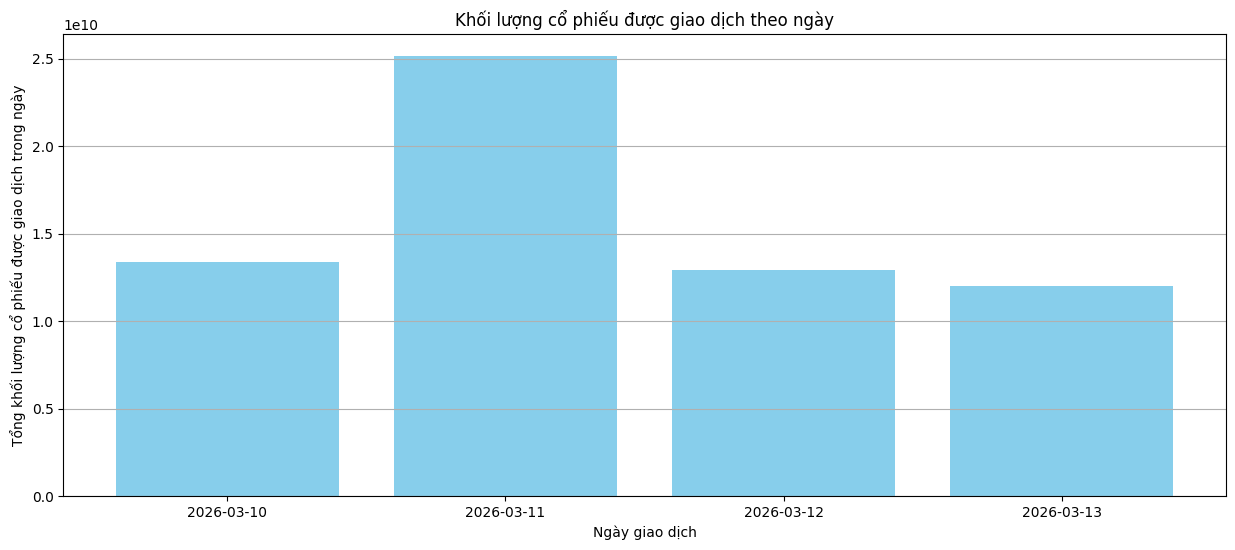

In [ ]:
# Thống kê khối lượng cổ phiếu được giao dịch trong ngày
print("Thống kê khối lượng cổ phiếu được giao dịch trong ngày:")
result_df = spark_df_candles\
    .withColumn("Ngày giao dịch", F.to_date(F.col("candle_time_stamp")))\
    .groupBy("Ngày giao dịch")\
    .agg(F.sum("candle_volume").alias("Tổng khối lượng cổ phiếu được giao dịch trong ngày"))\
    .orderBy(F.col("Ngày giao dịch"))\
    .toPandas()
    
# Vẽ biểu đồ
plt.figure(figsize=(15, 6))
plt.bar(result_df["Ngày giao dịch"], result_df["Tổng khối lượng cổ phiếu được giao dịch trong ngày"], color='skyblue')
plt.xlabel('Ngày giao dịch')
plt.ylabel('Tổng khối lượng cổ phiếu được giao dịch trong ngày')
plt.title('Khối lượng cổ phiếu được giao dịch theo ngày')
plt.xticks(result_df["Ngày giao dịch"])  # Đảm bảo tất cả các khung giờ được hiển thị
plt.grid(axis='y')
plt.show()

Thống kê khối lượng cổ phiếu được giao dịch trong ngày:


26/03/16 15:11:48 WARN TaskSetManager: Stage 200 contains a task of very large size (1006 KiB). The maximum recommended task size is 1000 KiB.


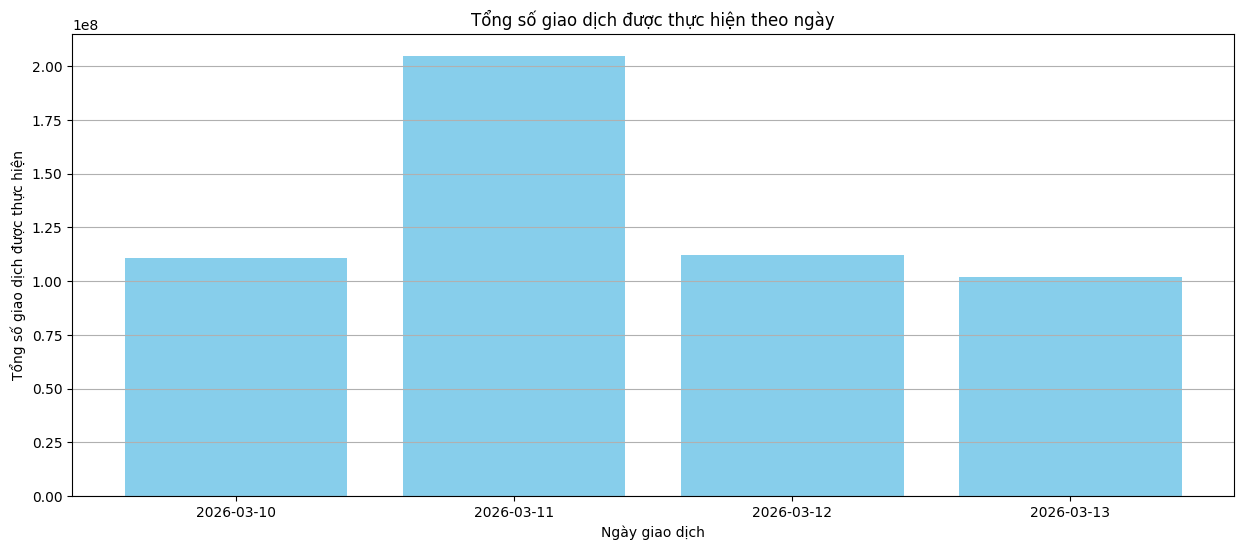

In [54]:
# Thống kê khối lượng cổ phiếu được giao dịch trong ngày
print("Thống kê khối lượng cổ phiếu được giao dịch trong ngày:")
result_df = spark_df_candles\
    .withColumn("Ngày giao dịch", F.to_date(F.col("candle_time_stamp")))\
    .groupBy("Ngày giao dịch")\
    .agg(F.sum("candle_num_of_trades").alias("Tổng số giao dịch được thực hiện"))\
    .orderBy(F.col("Ngày giao dịch"))\
    .toPandas()
    
# Vẽ biểu đồ
plt.figure(figsize=(15, 6))
plt.bar(result_df["Ngày giao dịch"], result_df["Tổng số giao dịch được thực hiện"], color='skyblue')
plt.xlabel('Ngày giao dịch')
plt.ylabel('Tổng số giao dịch được thực hiện')
plt.title('Tổng số giao dịch được thực hiện theo ngày')
plt.xticks(result_df["Ngày giao dịch"])  # Đảm bảo tất cả các khung giờ được hiển thị
plt.grid(axis='y')
plt.show()

## C. Phân tích kết hợp Dim Companies và Fact Candles

In [55]:
# Kết hợp hai bảng dựa trên company_id và candle_company_id
joined_df = spark_df_candles.join(spark_df_companies_filtered, spark_df_candles.candle_company_id == spark_df_companies_filtered.company_id)

joined_df.show(5)

26/03/16 15:13:31 WARN TaskSetManager: Stage 208 contains a task of very large size (1006 KiB). The maximum recommended task size is 1000 KiB.
26/03/16 15:13:32 WARN TaskSetManager: Stage 209 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


+---------+-----------------+-------------+----------------------+-----------+------------+-----------+----------+-------------------+--------------------+-------------+----------+--------------------+--------------------+--------------+-------------------+--------------------+----------------+-------------------+---------------------+-------------------+---------------------+-----------------------+--------------------+--------------------+
|candle_id|candle_company_id|candle_volume|candle_volume_weighted|candle_open|candle_close|candle_high|candle_low|  candle_time_stamp|candle_num_of_trades|candle_is_otc|company_id|        company_name|  company_time_stamp|company_ticket|company_is_delisted|    company_category|company_currency|   company_location|company_exchange_name|company_region_name|company_industry_name|company_industry_sector|company_sic_industry|  company_sic_sector|
+---------+-----------------+-------------+----------------------+-----------+------------+-----------+-----

In [59]:
# Thống kê khối lượng giao dịch trung bình theo ngành công nghiệp
print('Thống kê khối lượng giao dịch trung bình theo ngành công nghiệp')
joined_df\
    .groupBy("company_industry_sector")\
    .agg(F.avg("candle_volume").alias("Khối lượng trung bình"))\
    .orderBy("Khối lượng trung bình", ascending=False)\
    .withColumnRenamed("company_industry_sector", "Ngành")\
    .show()
    
# Thống kê khối lượng giao dịch trung bình theo ngành công nghiệp SIC
print('Thống kê khối lượng giao dịch trung bình theo ngành công nghiệp SIC')
joined_df\
    .groupBy("company_sic_sector")\
    .agg(F.avg("candle_volume").alias("Khối lượng trung bình"))\
    .orderBy("Khối lượng trung bình", ascending=False)\
    .withColumnRenamed("company_sic_sector", "Ngành SIC")\
    .show()

Thống kê khối lượng giao dịch trung bình theo ngành công nghiệp


26/03/16 15:16:33 WARN TaskSetManager: Stage 223 contains a task of very large size (1006 KiB). The maximum recommended task size is 1000 KiB.
26/03/16 15:16:33 WARN TaskSetManager: Stage 224 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+---------------------+
|               Ngành|Khối lượng trung bình|
+--------------------+---------------------+
|              Energy|    3858503.796551724|
|          Technology|   3578897.5128354724|
|  Consumer Defensive|    2867875.931283906|
|           Utilities|   2607468.8118393235|
|     Basic Materials|   2334672.7395833335|
|   Consumer Cyclical|    2102855.646983312|
|Communication Ser...|    2053199.397670549|
|  Financial Services|     1863818.79535026|
|         Real Estate|   1600530.4321206743|
|          Healthcare|    1519126.415615485|
|         Industrials|    1235281.997562165|
+--------------------+---------------------+

Thống kê khối lượng giao dịch trung bình theo ngành công nghiệp SIC


26/03/16 15:16:34 WARN TaskSetManager: Stage 232 contains a task of very large size (1006 KiB). The maximum recommended task size is 1000 KiB.
26/03/16 15:16:34 WARN TaskSetManager: Stage 233 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+---------------------+
|           Ngành SIC|Khối lượng trung bình|
+--------------------+---------------------+
|              Mining|    4180408.445727483|
|            Services|            2572031.0|
|Transportation Co...|    2370500.739490823|
|       Manufacturing|   2230771.5009848983|
|        Retail Trade|   1890829.1784989857|
|     Wholesale Trade|    1573131.692631579|
|Finance Insurance...|   1362899.5140745954|
|        Construction|    905187.7138157894|
|Agriculture Fores...|    738143.6280991735|
+--------------------+---------------------+



In [60]:
# Top 10 công ty có tổng khối lượng giao dịch nhiều nhất hiện tại
print('Top 10 công ty có tổng khối lượng giao dịch nhiều nhất hiện tại')
joined_df\
    .groupBy("company_name")\
    .agg(
        F.sum("candle_volume").alias("Tổng khối lượng cổ phiếu được giao dịch"),
        F.sum("candle_num_of_trades").alias("Tổng số giao dịch được thực hiện")
    )\
    .orderBy("Tổng khối lượng cổ phiếu được giao dịch", ascending=False)\
    .withColumnRenamed("company_name", "Tên công ty")\
    .limit(10)\
    .show()

Top 10 công ty có tổng khối lượng giao dịch nhiều nhất hiện tại


26/03/16 15:17:03 WARN TaskSetManager: Stage 241 contains a task of very large size (1006 KiB). The maximum recommended task size is 1000 KiB.
26/03/16 15:17:04 WARN TaskSetManager: Stage 242 contains a task of very large size (4373 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+---------------------------------------+--------------------------------+
|         Tên công ty|Tổng khối lượng cổ phiếu được giao dịch|Tổng số giao dịch được thực hiện|
+--------------------+---------------------------------------+--------------------------------+
|ACTELIS NETWORKS INC|                              785462420|                          920733|
|        KALA BIO INC|                              616001366|                          820157|
|         NVIDIA CORP|                              607311860|                         8360947|
|     T/R SYSTEMS INC|                              543863571|                             207|
|AMERICAN AIRLINES...|                              400107042|                          693271|
|           ONDAS INC|                              386111867|                         1144869|
|          UIPATH INC|                              381096109|                         1093283|
|EIGHTCO HOLDINGS INC|                  

## D. QUAN SÁT VÀ PHÂN TÍCH DIM_NEWS

In [ ]:
duck_conn = duckdb.connect(database='/home/nvkhoa14/stock-data-engineering/datawarehouse.duckdb')
query = 'SELECT * FROM dim_news'
pandas_df = duck_conn.execute(query).fetchdf()

duck_conn.close()

In [65]:
# Loại bỏ các cột không cần thiết
pandas_df.drop(columns=['new_title', 'new_url', 'new_authors', 'new_summary', 'news_time_id'], inplace=True)

# Chuyển đổi kiểu dữ liệu
pandas_df['new_time_published'] = pd.to_datetime(pandas_df['new_time_published'], format='%Y%m%dT%H%M%S')

pandas_df

,new_id,new_time_published,new_source,new_overall_sentiment_score,new_overall_sentiment_label
0,1,2026-03-10 12:00:00,GlobeNewswire,-0.648288,Bearish
1,2,2026-03-10 12:00:00,Investing.com Canada,-0.230997,Somewhat-Bearish
2,3,2026-03-10 11:59:58,Stock Titan,-0.615916,Bearish
3,4,2026-03-10 11:59:55,Financial Times,0.491483,Bullish
4,5,2026-03-10 11:59:47,Business Wire,0.429521,Bullish
...,...,...,...,...,...
5846,5847,2026-03-13 20:20:09,Stock Titan,-0.408881,Bearish
5847,5848,2026-03-13 20:20:04,TradingView,-0.239249,Somewhat-Bearish
5848,5849,2026-03-13 20:20:00,Stock Traders Daily,0.042624,Neutral
5849,5850,2026-03-13 20:19:09,AD HOC NEWS,0.207252,Somewhat-Bullish


In [66]:
# Chuyển đổi Pandas DataFrame thành PySpark DataFrame với schema
spark_df_news = spark.createDataFrame(pandas_df)

# Hiển thị một vài hàng của DataFrame
print(spark_df_news.count())
spark_df_news.show()

5851
+------+-------------------+--------------------+---------------------------+---------------------------+
|new_id| new_time_published|          new_source|new_overall_sentiment_score|new_overall_sentiment_label|
+------+-------------------+--------------------+---------------------------+---------------------------+
|     1|2026-03-10 12:00:00|       GlobeNewswire|                  -0.648288|                    Bearish|
|     2|2026-03-10 12:00:00|Investing.com Canada|                  -0.230997|           Somewhat-Bearish|
|     3|2026-03-10 11:59:58|         Stock Titan|                  -0.615916|                    Bearish|
|     4|2026-03-10 11:59:55|     Financial Times|                   0.491483|                    Bullish|
|     5|2026-03-10 11:59:47|       Business Wire|                   0.429521|                    Bullish|
|     6|2026-03-10 11:59:40|         Stock Titan|                   0.279533|           Somewhat-Bullish|
|     7|2026-03-10 11:59:39|      Nationa

In [67]:
# Số lượng bài báo từ các nguồn
print('Số lượng bài báo từ các nguồn')
spark_df_news\
    .groupBy("new_source")\
    .agg(F.count("new_id").alias("Tổng số bài báo được phát hành"))\
    .orderBy("Tổng số bài báo được phát hành", ascending=False)\
    .withColumnRenamed("new_source", "Nguồn")\
    .show()

Số lượng bài báo từ các nguồn
+-------------------+------------------------------+
|              Nguồn|Tổng số bài báo được phát hành|
+-------------------+------------------------------+
|         MarketBeat|                          1958|
|        Stock Titan|                           415|
|        AD HOC NEWS|                           307|
|        TradingView|                           266|
|     National Today|                           165|
|     Insider Monkey|                           163|
|                MSN|                           141|
|     Simply Wall St|                           139|
| Simply Wall Street|                           131|
|      Investing.com|                           121|
|          GuruFocus|                           101|
|             Bitget|                            94|
|               Sahm|                            92|
|           TipRanks|                            88|
|Stock Traders Daily|                            85|
| The Globe and 

Số lượng bài báo thoe các khung giờ


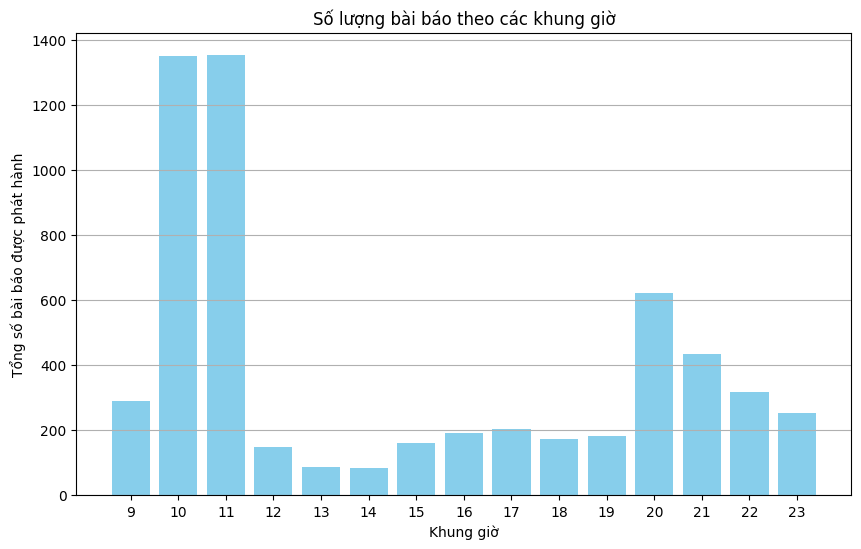

In [68]:
# Số lượng bài báo thoe các khung giờ
print('Số lượng bài báo thoe các khung giờ')
result_df = spark_df_news\
    .withColumn("hour", F.hour("new_time_published"))\
    .groupBy("hour")\
    .agg(F.count("new_id").alias("Tổng số bài báo được phát hành"))\
    .withColumnRenamed("hour", "Khung giờ")\
    .orderBy("Khung giờ")\
    .toPandas()
    
# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.bar(result_df["Khung giờ"], result_df["Tổng số bài báo được phát hành"], color='skyblue')
plt.xlabel('Khung giờ')
plt.ylabel('Tổng số bài báo được phát hành')
plt.title('Số lượng bài báo theo các khung giờ')
plt.xticks(result_df["Khung giờ"])  # Đảm bảo tất cả các khung giờ được hiển thị
plt.grid(axis='y')
plt.show()